# Optimizing Feature Selection using Simulated Annealing

## Introduction

In my current role, I've developed and deployed several of predictive models that span the entire student lifecycle. These models estimate the likelihood that a prospective student apply or enroll or the likelihood that an enrolled student will retain or graduate. But determining which features to include in a model can be daunting. The process generally involves a lot of exploratory data analysis - wherein I examine each feature and its relationship with the outcome - as well as a lot of trial and error. This process is slow, tedious, and can miss interactions between terms - especially as the number of features grows. 

In the past, I've used evolutionary algorithms to optimize other [solutions](https://htmlpreview.github.io/?https://github.com/jason-hanser/block-schedule/blob/master/block-schedule-walkthrough-p1.html) and figured I could use a similar approach to automate this process. Here, I develop a program to optimize feature selection for a retention model using simulated annealing. The program considers not only main effects, but also potential interactions between terms. The hope is that I could use this framework to build better models in the future. 



## Data & Packages

To start, we will load some packages and the data we are interested in modeling. Minus a bit of pre-processing, this data set has already been cleaned as I don't want to spend a ton of time explaining that process. And similar to other higher ed projects shared on this site, the data used here is student-level data and - as a result - not available for download. However, it contains four years of enrolled student and retention data, consisting of roughly a hundred thousand rows and forty potential variables - such as cumulative GPA, prior term GPA, sex, residency, college/school, etc.


In [ ]:
## loading libraries

import numpy             as np
import pandas            as pd
import seaborn           as sns
import matplotlib.pyplot as plt
import random  

from itertools             import combinations
from sklearn.linear_model  import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics       import roc_auc_score
from sklearn.metrics       import f1_score

## loading data

df_retain = pd.read_csv("clean_data.csv")


## basic set of variables to use 

current_variables  = ['IN_RESD_N', 'IN_PRIOR_TERM_GPA', 'IN_CUML_GPA']



## Functions

This project will require multiple functions. 

First, we need to create a function that will modify the slate of variables we are using in each iteration. The function below takes our current slate of variables and the full list of potential variables. The function then adds or removes a term at random. When adding a term, the function will either add a main effect from the full list of potential variables. Or, the function will create a two-way interaction from the variables currently being used. When removing a term, we remove the selected term as well as any dependent interaction terms. For example, if we remove IN_RESD_N - we would also remove IN_RESD_N:IN_CUML_GPA. This framework could be extended to include three-way interactions, but I decided to limit it to two-way interactions.

In [2]:
def change_variables(vars, all_vars, min_terms = 5, max_terms = 35):

    temp_all_main_effects   = sorted(all_vars)
    temp_curr_main_effects  = sorted([x for x in vars if x in temp_all_main_effects])
    temp_2_way_interactions = [':'.join(x) for x in combinations(temp_curr_main_effects, 2)]
        
    ## randomly removing a variable(s) (& any higher order terms that rely on that variable)
    if (random.random() < 0.50 and len(vars) > min_terms) or len(vars) >= max_terms:
        
        ## randomly removing a term & any higher order terms that rely on that variable
        
        temp_subtract_var = random.choice(vars)
        temp_subtract_var = [temp_subtract_var] + [x for x in vars if all(y in x for y in temp_subtract_var.split(':'))]
        temp_subtract_var = list(set(temp_subtract_var))

        vars = [x for x in vars if x not in temp_subtract_var]
        
            
    ## randomly adding variable(s)
    else:
        
        ## adding a main effect
        if (random.random() < 0.75 and len(set(temp_all_main_effects) - set(vars)) > 0):
            
            temp_add_var = random.choice(list(set(temp_all_main_effects) - set(vars)))
        
            vars.append(temp_add_var)
        
        ## adding a two way interction from the current main effects in vars
        elif (len(set(temp_2_way_interactions) - set(vars)) > 0):
            
            temp_add_var = random.choice(list(set(temp_2_way_interactions) - set(vars)))  
                        
            vars.append(temp_add_var)
                
    ## returning the new variables
    
    return vars
            

Next, we need to create a function that will process our data frame based on our slate of variables. The function below takes a data frame and a list of variables - including interaction terms (e.g. "IN_RESD_N:IN_PRIOR_TERM_DWF") - and creates a data frame with the values for those terms. The function also scales all of our numeric variables in order to minimize the likelihood of a convergence error. When scaling numerical variables, we group by term to minimize any effect of drift over time (e.g. grade inflation).

In [3]:

def pre_process(data, vars):
    
    ## getting non input columns
    temp_keep_cols = [x for x in data.columns if x.startswith('KEEP_')]
    temp_out_cols  = [x for x in data.columns if x.startswith('OUT_')]
    
    ## splitting out interaction terms
    temp_interactions = [x for x in vars if ':' in x]

    if len(temp_interactions) > 0:

        ## calculating interaction values    
        for i in temp_interactions:
            
            temp_main_effects = i.split(':')
            
            data[i] = data[temp_main_effects].prod(1)
        
    
    ## scaling numerical variables by focal term
    
        temp_numeric_cols = [x for x in data[vars].columns if data[x].nunique() > 2]
        
        if len(temp_numeric_cols) > 0:
    
            def scale_data_by_group(data):        
                
                data_scaled = data.copy()
                
                data_scaled[temp_numeric_cols] = StandardScaler().fit_transform(data[temp_numeric_cols])
            
                return data_scaled
        
        
            data_scaled = data.groupby('KEEP_TERM_DESC', group_keys = False).apply(scale_data_by_group, include_groups = False)
        
            data[temp_numeric_cols] = data_scaled[temp_numeric_cols]
               
        
    ## putting the data frame back together and returning it
    
    data = data[temp_keep_cols + vars + temp_out_cols]
    return data
    
    

The next function trains a logistic regression model using our processed data frame and list of features. And we calculate a couple of fit statistics - AUC and F1 score - for the model using a five-fold cross-validation approach. While I am calculating both AUC and F1 score, AUC will be used to score each model.

In [4]:
def model_data(data, vars):
         
    ## initilizing df to store fit statistics
        
    df_model_fit = pd.DataFrame()
                     
    ## creating training data set and splitting it into five folds for cross-validation 
    
    train_data = data.loc[data['KEEP_MODEL_SPLIT'] == "TRAIN"]
    train_data = train_data.reset_index()
    train_data['CV_FOLD'] = train_data.index % 5
    
    ## cross validation loop
    for i in range(5):
    
        ## prepping training data 
        temp_train = train_data.loc[train_data['CV_FOLD'] != i]

        temp_train = temp_train.sample(n = 20000, weights = 'KEEP_TERM_WEIGHT', replace = True)
        temp_train = temp_train.reset_index()

        temp_train_x = temp_train[vars]
        temp_train_y = temp_train['OUT_RETAIN']

        ## prepping cross-validation data
        temp_valid = train_data.loc[train_data['CV_FOLD'] == i]        

        temp_valid_x = temp_valid[vars]
        temp_valid_y = temp_valid['OUT_RETAIN']
                        
        ## fitting data to model & getting predictions
        
        temp_model = LogisticRegression(max_iter = 1000)
        temp_model.fit(temp_train_x, temp_train_y)
            
        temp_preds = temp_model.predict_proba(temp_valid_x)[:, 1]
            
        ## calculating fit statistics
        
        temp_results = pd.DataFrame()

        temp_results['CV_FOLD'] = [i]
        temp_results['AUC']     = [roc_auc_score(temp_valid_y, temp_preds)]
        temp_results['F1']      = [f1_score(temp_valid_y, temp_preds >= 0.5)]

        ## clean up
        
        df_model_fit = pd.concat([df_model_fit, temp_results])
          
    ## returning the model fit stats
    
    return df_model_fit      
     

And finally, we need a function that implements the simulated annealing algorithm. The function below takes a data frame containing the data we are modeling and our initial slate of variables. After fitting a model to the data using our initial slate of variables - the program enters a loop where the variables being considered change each iteration. Once a new model is fit to the data, the score of the new model is compared to the existing model. If the score of the new model is better, that model and its slate of variables are adopted. If the score of the new model is worse than the existing model, the new set of variables are adopted probabilistically based on the current temperature and the score of the new model relative to score of the existing model.

When the temperature is high, the program is more likely to adopt a worse alternative - in order to potentially escape a local minimum. However, as the temperate decreases, the likelihood of adopting a worse model decreases. As such, simulated annealing gradually shifts from exploration to exploitation.

The rate of this shift and the time spent exploring/exploiting possible solutions is dependent on three variables: starting temperature, cooling rate, and number of iterations. A high start temperature and slow cooling rate will increase the amount of time spent exploring solutions. Conversely, a low start temperature, fast cooling rate, greater number of iterations will increase the time spent exploiting solutions. Ideally, you want to strike a balance between these two so that you aren't locked into a local minimum (i.e. not enough exploring) nor are you constantly jumping around (i.e. not enough exploiting). There are some general guidelines for choosing these values, but it ultimately depends on your data/problem.


In [ ]:

def simulated_annealing(data, init_vars, start_temp = 100, cooling_rate = 0.99, max_iter = 1000):
    
    ############   
    ## SET UP ##
    ############
    
    random.seed(1850)
    
    model_scores = pd.DataFrame()
    
    all_vars     = [x for x in data.columns if x.startswith('IN_')]
    
    current_df   = data.copy()
    current_vars = init_vars.copy()
    
    temp         = start_temp
    

    ###################
    ## INITIAL MODEL ##
    ###################

    ## modeling data
    
    current_df    = pre_process(data = current_df, vars = current_vars)
    df_model_fit  = model_data(data  = current_df, vars = current_vars)
    
    df_model_fit['iter'] = 0        
    current_score        = sum(df_model_fit['AUC'])/len(df_model_fit['AUC'])*100
    
    model_scores = pd.concat([model_scores, df_model_fit])
        
    
    ##############################
    ## SIMULATED ANNEALING LOOP ##
    ##############################
    
    for i in range(1, max_iter+1):
           
        ## init data & getting new set of features
        
        new_df        = data.copy()
        new_variables = current_vars.copy()
        
        new_variables = change_variables(vars = new_variables, all_vars = all_vars, max_terms = 30)

        ## modeling the data
        
        new_df       = pre_process(data = new_df, vars = new_variables)   
        df_model_fit = model_data(data = new_df, vars = new_variables)
        
        df_model_fit['iter'] = i      
        new_score            = sum(df_model_fit['AUC'])/len(df_model_fit['AUC'])*100
        
        model_scores = pd.concat([model_scores, df_model_fit])
        
        ## accepting the new slate of features IF they are better OR probabilistically if they are worse
        
        if new_score > current_score or np.exp(-(current_score - new_score)/temp) > random.random():
            
            current_vars  = new_variables.copy()
            current_score = new_score
                        
        ## clean up & reducing the temperature
        
        temp = temp*cooling_rate
            
    
    ## returning the variables and some fit statistics
    
    return current_vars, model_scores
    

And having now finished the functions above, we can actually run the program and extract the results. 

In [6]:
## Running the Simulated Annealing program

random.seed(125)
SA_results = simulated_annealing(data = df_retain, init_vars = current_variables, start_temp = 20, cooling_rate = 0.99, max_iter = 1500)

## extracting final variables and fit statistics

SA_variables = SA_results[0]
SA_fit_stats = SA_results[1]


## Results

The plot below shows the average AUC of our cross-validation data over the course of the 1,500 iterations we ran. AUC rose quickly and erratically for the first 500 iterations, after which AUC increased more gradually before levelling off. Looking at the graph, I probably could have reduced the number of iterations - but oh well. 

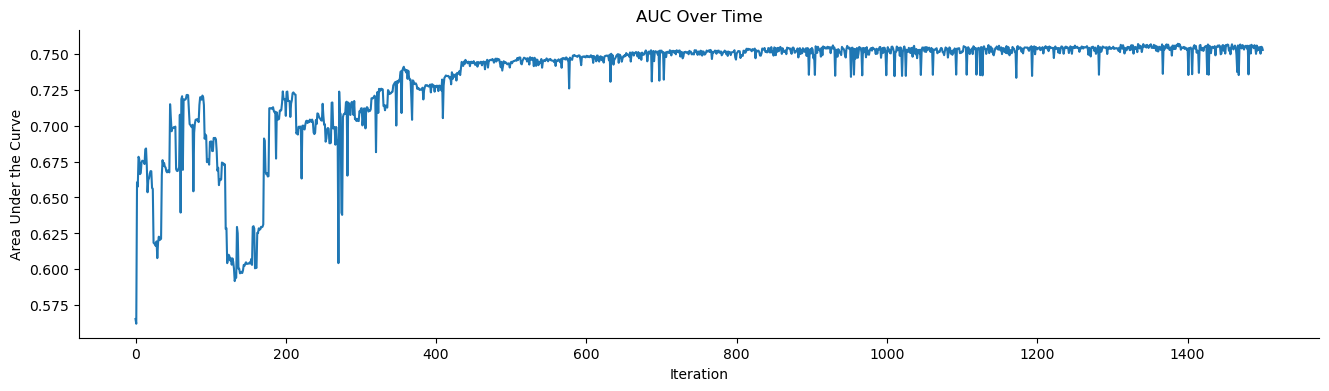

In [ ]:
## aggregating results
temp_fit = (SA_fit_stats
            .groupby('iter')
            .agg(AUC = ('AUC', 'mean'),
                 F1  = ('F1',  'mean'))
            .reset_index()
            )

## plotting results
fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(data = temp_fit, x = 'iter', y = 'AUC')
plt.title("AUC Over Time")
plt.xlabel("Iteration")
plt.ylabel("Area Under the Curve")
sns.despine()

Below is our "optimized" slate of features. While simulated annealing is billed an optimization algorithm, it doesn't necessarily guarantee an optimal solution - just near-optimal solution. As such, I may want to experiment with this list of features a bit - but this is a great starting point. 

In [15]:
print(SA_variables)

['IN_PRIOR_TERM_GPA', 'IN_CURR_HOURS', 'IN_HS_GPA', 'IN_ON_CAMPUS_Y', 'IN_CURR_COLLEGE_College of Nursing', 'IN_CUML_GPA', 'IN_TRANS_HOURS', 'IN_NEW_STUDENT_Y', 'IN_CUML_CAPSTONE_Y', 'IN_CUML_4000_LEVEL', 'IN_CUML_TERMS', 'IN_DEFER_Other/Unknown', 'IN_CUML_U_HOURS_EARNED', 'IN_AGE', 'IN_NEW_STUDENT_Y:IN_TRANS_HOURS', 'IN_CURR_DOUBLE_MAJOR_Y', 'IN_APPL_DATE', 'IN_PRIOR_TERM_DWF', 'IN_CURR_COLLEGE_College of Humanities', 'IN_CURR_COLLEGE_College of Social & Behavioral Science', 'IN_CURR_COLLEGE_Undergraduate Studies', 'IN_CURR_COLLEGE_School of Business', 'IN_CURR_COLLEGE_College of Fine Arts', 'IN_CUML_TERMS:IN_PRIOR_TERM_GPA', 'IN_CURR_HOURS:IN_PRIOR_TERM_DWF', 'IN_HS_GPA:IN_ON_CAMPUS_Y', 'IN_DEPOSIT_DATE', 'IN_CURR_COLLEGE_School of Medicine', 'IN_CUML_4000_LEVEL:IN_CURR_COLLEGE_College of Nursing', 'IN_CURR_COLLEGE_College of Education']


Next, we can apply the "optimized" slate of features to our test data. 

In [31]:
## processing data

df_new = pre_process(data = df_retain, vars = SA_variables)

## splitting out training data and re-sampling it

train_data = df_new.loc[df_new['KEEP_MODEL_SPLIT'] == "TRAIN"]
train_data = train_data.sample(n = 100000, weights = 'KEEP_TERM_WEIGHT', replace = True)
train_data = train_data.reset_index()

## seperating training and test data

temp_train_x = train_data[SA_variables]
temp_train_y = train_data['OUT_RETAIN'].squeeze()

temp_test_x  = df_new.loc[df_new['KEEP_MODEL_SPLIT'] == "TEST", SA_variables]
temp_test_y  = df_new.loc[df_new['KEEP_MODEL_SPLIT'] == "TEST", 'OUT_RETAIN'].squeeze()

## fitting model to data and getting predictions

temp_model = LogisticRegression(max_iter = 1000)
temp_model.fit(temp_train_x, temp_train_y)    

temp_preds = temp_model.predict_proba(temp_test_x)[:, 1]


Our final model had an AUC of 0.76 and an F1 score of 0.94 on our test data. The relatively high F1 score compared to AUC is likely the result of our imbalanced data - roughly 90% of students retain. While an AUC of 0.76 may not seem particularly impressive, it's not bad considering the nature of student retention. The reality is that students drop out for a variety of reasons (e.g. death of a family member, personal health reasons, their boyfriend is transferring to another school), but we typically only have academic indicators at our disposal. 

In [ ]:
## fit stats
print("Prediction Performance")
print(f"AUC-ROC:    {round(roc_auc_score(temp_test_y, temp_preds), 3)}")
print(f"F1 Score:   {round(f1_score(temp_test_y, temp_preds >= 0.5), 3)}")

Prediction Performance
AUC-ROC:    0.767
F1 Score:   0.944


# Final Remarks

In general, this has worked out pretty well. I definitely think I could generalize the code a bit more so that I could apply it to a wider variety of models, but that's beyond the scope of this write up. 